# Séance 1 - Bonus : Première régularisation d'un réseau de neurones

Pour poursuivre le travail du TP, on se propose d'explorer une première manière de régulariser un réseau de neurones. Nous avons vu que nous pouvions atteindre de bonne performances, mais que cela entraînait fréquemment un sur-apprentissage. 
Une des premières manières de régulariser que l'on apprend en Machine Learning est de pénaliser une régression linéaire : c'est la régression Ridge. Le principe est de modifier la fonction de perte pour contraindre les poids appris à être *petit*. Il est possible de le faire couche par couche dans un réseau de neurones. Essayons !

Commençons par importer et traiter les données.

In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

(X_train_full, y_train_full), (X_test, y_test) = (keras.datasets.mnist.load_data())
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, train_size=0.8)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.astype(np.float32).reshape(-1, 28 * 28)).reshape(-1, 28, 28)
X_valid = scaler.transform(X_valid.astype(np.float32).reshape(-1, 28 * 28)).reshape(-1, 28, 28)
X_test = scaler.transform(X_test.astype(np.float32).reshape(-1, 28 * 28)).reshape(-1, 28, 28)

## Pénalisation $L_2$

La pénalisation à laquelle on s'intéresse ici est la pénalisation $L_2$. Si l'on considère un problème d'optimisation d'une fonction de perte $\mathcal{L}$

$$w^* = \arg\min_{w\in\mathbb{R}^d} \mathcal{L}(w)$$

Alors sa version pénalisée est la suivante avec $\lambda > 0$ :

$$w^* = \arg\min_{w\in\mathbb{R}^d} \mathcal{L}(w) + \lambda\|w\|^2$$

Ce n'est plus exactement le même objectif puisqu'on force ici le vecteur solution $w^*$ a prendre de plus petite valeurs. Nous pouvons faire cela couche par couche.

**Consigne** : Définir un modèle en ajoutant une pénalisation [$L_2$](https://keras.io/api/layers/regularizers/#l2-class) aux couches [`Dense`](https://keras.io/api/layers/core_layers/dense/).

In [2]:
model = keras.models.Sequential(
    [
        keras.layers.Input(shape=[28, 28]),
        keras.layers.Flatten(),
        keras.layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.Dense(10, activation="softmax"),
    ]
)


**Consigne** : Lancer sur quelques époques le modèle pour valider qu'il fonctionne correctement.

In [3]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.SGD(learning_rate=1e-3),
    metrics=["accuracy"],
)

epochs = 5
batch_size = 32

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_valid, y_valid),
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6333 - loss: 1.8730 - val_accuracy: 0.8069 - val_loss: 1.3328
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8519 - loss: 1.1420 - val_accuracy: 0.8643 - val_loss: 1.0756
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8861 - loss: 0.9830 - val_accuracy: 0.8863 - val_loss: 0.9850
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9014 - loss: 0.9122 - val_accuracy: 0.8977 - val_loss: 0.9364
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 999us/step - accuracy: 0.9112 - loss: 0.8692 - val_accuracy: 0.9056 - val_loss: 0.9040


De la même manière que l'on souhaitais observer l'impact du learning rate sur l'entraînement, on souhaite mesurer l'apport de la régularisation au modèle. 

## Mesure de l'impact de la régularisation

**Consigne** : Définir une fonction `get_model` qui prend en paramètre :
* *lambda_l2* : float correspondant à la magnitude de la pénalisation $L_2$
* *learning_rate* : float par défaut à $0.001$ correspond au learning rate de l'optimizer

La fonction renvoie le modèle compilé.

In [4]:
def get_model(lambda_l2: float, learning_rate: float) -> keras.Model:
    model = keras.models.Sequential(
        [
            keras.layers.Input(shape=[28, 28]),
            keras.layers.Flatten(),
            keras.layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(lambda_l2)),
            keras.layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(lambda_l2)),
            keras.layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=keras.optimizers.SGD(learning_rate=learning_rate),
        metrics=["accuracy"],
    )
    return model

**Consigne** : En s'inspirant du travail réalisé pour le learning rate, comparer différente valeur de régularisation. Commenter.

In [ ]:
n_epochs = 30
batch_size = 256
learning_rates = [10 ** (-power) for power in range(1, 4)]
lambda_l2_values = [0.001, 0.01, 0.1]

results = []
for learning_rate in learning_rates:
    for lambda_l2 in lambda_l2_values:
        model = get_model(lambda_l2, learning_rate)
        history = model.fit(
            X_train,
            y_train,
            epochs=n_epochs,
            batch_size=batch_size,
            validation_data=(X_valid, y_valid),
            verbose=0,
        )
        results.append(
            {
                "learning_rate": learning_rate,
                "lambda_l2": lambda_l2,
                "history": pd.DataFrame(history.history),
                "n_epochs": n_epochs,
            }
        )

In [9]:
def show_results(results: list) -> None:
    plt.figure(figsize=(12, 4))

    for _, result in enumerate(results):
        history_df = result["history"]
        learning_rate = result["learning_rate"]
        lambda_l2 = result["lambda_l2"]

        plt.subplot(1, 2, 1)
        plt.plot(history_df["val_loss"], label=f"LR={learning_rate}, L2={lambda_l2}")
        plt.xlabel("Epochs")
        plt.ylabel("Validation Loss")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history_df["val_accuracy"], label=f"LR={learning_rate}, L2={lambda_l2}")
        plt.xlabel("Epochs")
        plt.ylabel("Validation Accuracy")
        plt.legend()

    plt.show()


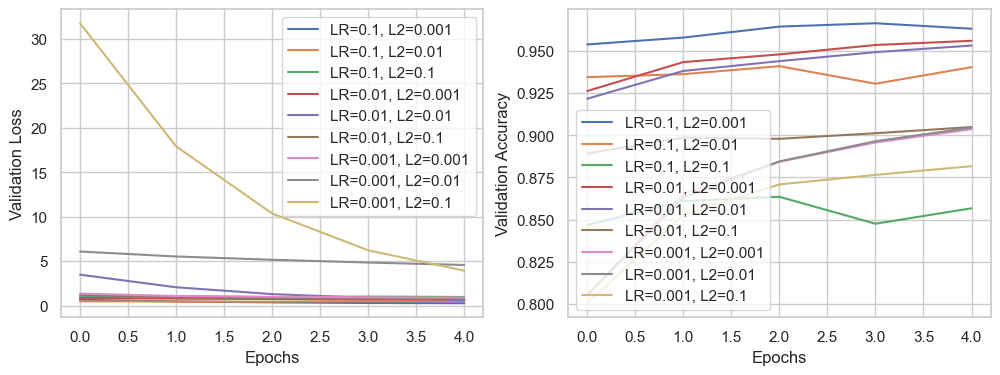

In [10]:
show_results(results)